In [1]:
import sys
import os
import matplotlib.pyplot as plt
import numpy as np
from numba import njit, prange

# plt.style.use("./science.mplstyle")

import smplotlib

codedir = "../src/"

sys.path.append(os.path.abspath(codedir))

from axisymmetric_stability import *


# Rafikov dispersion relationship

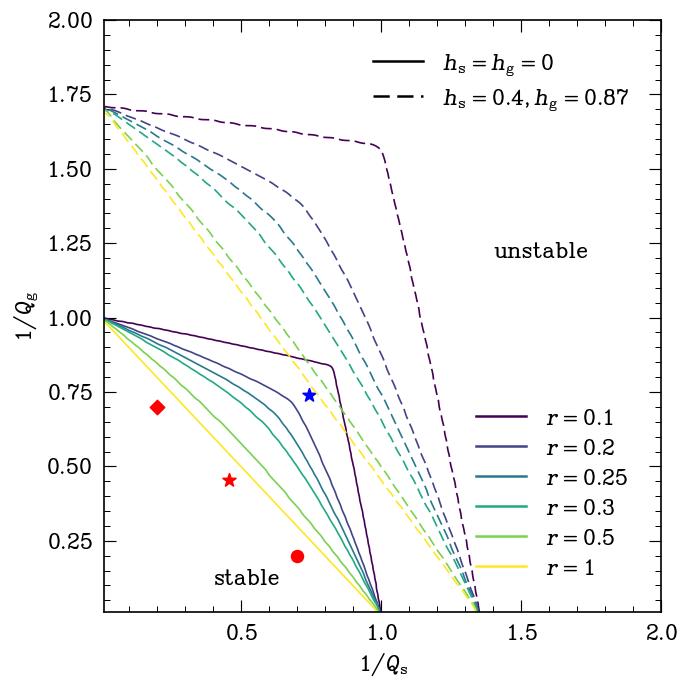

In [2]:
import sys
sys.path.insert(0, '../src')
from paper_case_points import (
    POINTS_THIN_DISKS as points_thin_disks,
    POINTS_THICK_DISKS as points_thick_disks,
    THIN_DISK_MARKERS as thin_disk_marker,
    THICK_DISK_MARKERS as thick_disk_marker,
    scatter_marker_size,
)

from scipy.ndimage import gaussian_filter
from matplotlib.lines import Line2D

# -----------------------------
# Thin disk plots
# -----------------------------
inv_q_axis = np.linspace(0.01, 1.2, 200)
Qg_vec = 1.0 / inv_q_axis
Qs_vec = 1.0 / inv_q_axis

r_ratios = [0.1, 0.2, 0.25, 0.3, 0.5, 1]
colors = plt.cm.viridis(np.linspace(0, 1, len(r_ratios)))

for R, color in zip(r_ratios, colors):
    Z = get_stability_boundary_thick_disk(R, Qg_vec, Qs_vec, 0, 0)

    Z_smooth = gaussian_filter(Z, sigma=1.5)

    plt.contour(
        1 / Qg_vec,
        1 / Qs_vec,
        Z_smooth,
        levels=[0.5],
        colors=[color],
        linewidths=1,
        linestyles="solid"
    )


# -----------------------------
# Thick disk plots
# -----------------------------
inv_q_axis = np.linspace(0.01, 2.0, 200)
Qg_vec = 1.0 / inv_q_axis
Qs_vec = 1.0 / inv_q_axis

for R, color in zip(r_ratios, colors):
    Z = get_stability_boundary_thick_disk(R, Qg_vec, Qs_vec, 0.87, 0.4)

    Z_smooth = gaussian_filter(Z, sigma=1.5)

    plt.contour(
        1 / Qg_vec,
        1 / Qs_vec,
        Z_smooth,
        levels=[0.5],
        colors=[color],
        linewidths=1,
        linestyles="dashed"
    )

# -----------------------------
# Labels and annotations
# -----------------------------
plt.xlabel(r'$1/Q_{\mathrm{s}}$')
plt.ylabel(r'$1/Q_{\mathrm{g}}$')

plt.text(0.4, 0.1, 'stable')
plt.text(1.4, 1.2, 'unstable')


# -----------------------------
# Compact legends
# -----------------------------

# Legend for colors / R values
R_handles = [
    Line2D([0], [0], color=color, lw=1.5, label=rf'$r = {R}$')
    for R, color in zip(r_ratios, colors)
]

legend_R = plt.legend(
    handles=R_handles,
    loc='lower right',
)

plt.gca().add_artist(legend_R)


# Legend for line styles
style_handles = [
    Line2D([0], [0], color='black', lw=1.5, ls='solid', label=r'$h_{\mathrm{s}} = h_{\mathrm{g}} = 0$'),
    Line2D([0], [0], color='black', lw=1.5, ls='dashed', label=r'$h_{\mathrm{s}} = 0.4, h_{\mathrm{g}} = 0.87$')
]

plt.legend(
    handles=style_handles,
    loc='upper right'
)

# -----------------------------
# Scatter points [Qs, Qg]
# -----------------------------


# Thick disk points
for point, marker in zip(points_thick_disks, thick_disk_marker):
    Qs, Qg = point

    plt.scatter(1.0 / Qs, 1.0 / Qg, marker=marker, s=scatter_marker_size(marker), color='blue')


# Thin disk points
for point, marker in zip(points_thin_disks, thin_disk_marker):
    Qs, Qg = point

    plt.scatter(1.0 / Qs, 1.0 / Qg, marker=marker, s=scatter_marker_size(marker), color='red')
#-----------------------------

plt.tight_layout()
plt.savefig("./Figures/Rafikov_dispersion.pdf")
plt.show()